In [3]:
# -------------------------------------------------
# 1️⃣  Import necessary libraries
# -------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit‑learn utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC          # Linear SVM works well for text
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# For reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [4]:
# -------------------------------------------------
# 2️⃣  Load a sample text‑classification dataset
# -------------------------------------------------
# Example: the built‑in "20 Newsgroups" subset (you can replace with your own CSV)
from sklearn.datasets import fetch_20newsgroups

# Fetch a small subset for speed (feel free to change categories)
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
newsgroups = fetch_20newsgroups(subset='all', categories=categories,
                                shuffle=True, random_state=RANDOM_SEED,
                                remove=('headers', 'footers', 'quotes'))

# Put into a DataFrame for easier handling
df = pd.DataFrame({'text': newsgroups.data, 'label': newsgroups.target})
df['label_name'] = df['label'].map(lambda i: newsgroups.target_names[i])

# Quick look
df.head()

,text,label,label_name
0,\nWhere did you read this? I don't think this...,2,sci.med
1,[Someone quoted the following. I've removed t...,3,soc.religion.christian
2,\n,3,soc.religion.christian
3,I've been away for a couple of weeks and have ...,1,comp.graphics
4,FYI...I just posted this on alt.psychoactives ...,2,sci.med


C:\Users\anas1\AppData\Local\Temp\ipykernel_21428\3011194835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label_name', palette='viridis')


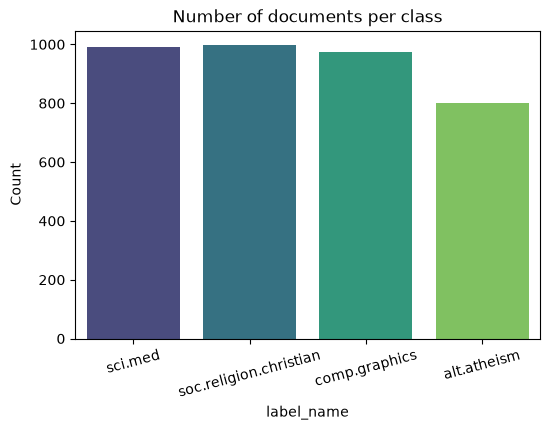

In [5]:
# -------------------------------------------------
# 3️⃣  Simple EDA: class distribution
# -------------------------------------------------
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label_name', palette='viridis')
plt.xticks(rotation=15)
plt.title('Number of documents per class')
plt.ylabel('Count')
plt.show()

In [6]:
# -------------------------------------------------
# 4️⃣  Split data into training and test sets
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'],
    test_size=0.2,
    stratify=df['label'],      # keep class ratios
    random_state=RANDOM_SEED
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

Training samples: 3007
Test samples:     752


In [7]:
# -------------------------------------------------
# 5️⃣  Convert raw text to TF‑IDF feature vectors
# -------------------------------------------------
tfidf = TfidfVectorizer(
    stop_words='english',   # drop common English stop words
    max_df=0.95,            # ignore terms that appear in >95% of docs
    min_df=2,               # ignore terms that appear in <2 docs
    ngram_range=(1,2),      # unigrams + bigrams often help
    sublinear_tf=True       # apply log scaling to term frequency
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print(f"Shape of training matrix: {X_train_vec.shape}")
print(f"Shape of test matrix:     {X_test_vec.shape}")

Shape of training matrix: (3007, 59239)
Shape of test matrix:     (752, 59239)


In [8]:
# -------------------------------------------------
# 6️⃣  Train a Linear SVM (default C=1.0)
# -------------------------------------------------
svm_clf = LinearSVC(random_state=RANDOM_SEED, max_iter=5000)
svm_clf.fit(X_train_vec, y_train)

# Predict on the test set
y_pred = svm_clf.predict(X_test_vec)

# Quick evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=newsgroups.target_names))

Accuracy: 0.8909574468085106

Classification Report:
                         precision    recall  f1-score   support

           alt.atheism       0.91      0.73      0.81       160
         comp.graphics       0.91      0.95      0.93       195
               sci.med       0.88      0.95      0.92       198
soc.religion.christian       0.87      0.89      0.88       199

              accuracy                           0.89       752
             macro avg       0.89      0.88      0.89       752
          weighted avg       0.89      0.89      0.89       752



In [9]:
# -------------------------------------------------
# 7️⃣  Tune the SVM regularization parameter C
# -------------------------------------------------
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    estimator=LinearSVC(random_state=RANDOM_SEED, max_iter=5000),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,               # 5‑fold cross‑validation
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_vec, y_train)

print("Best C:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best C: {'C': 10}
Best CV Accuracy: 0.8799398566066523


Tuned Model Accuracy: 0.8909574468085106

Classification Report (Tuned):
                         precision    recall  f1-score   support

           alt.atheism       0.89      0.74      0.81       160
         comp.graphics       0.93      0.95      0.94       195
               sci.med       0.87      0.95      0.91       198
soc.religion.christian       0.88      0.89      0.88       199

              accuracy                           0.89       752
             macro avg       0.89      0.88      0.89       752
          weighted avg       0.89      0.89      0.89       752



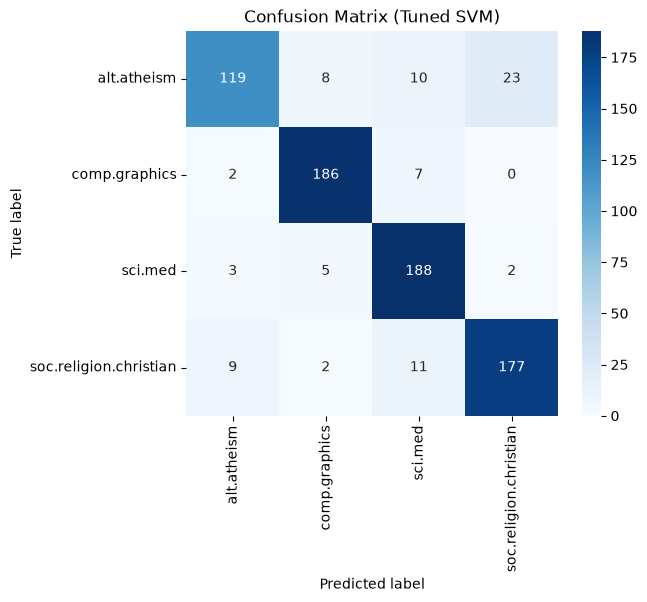

Tuned Model Accuracy: 0.8909574468085106

Classification Report (Tuned):
                         precision    recall  f1-score   support

           alt.atheism       0.89      0.74      0.81       160
         comp.graphics       0.93      0.95      0.94       195
               sci.med       0.87      0.95      0.91       198
soc.religion.christian       0.88      0.89      0.88       199

              accuracy                           0.89       752
             macro avg       0.89      0.88      0.89       752
          weighted avg       0.89      0.89      0.89       752



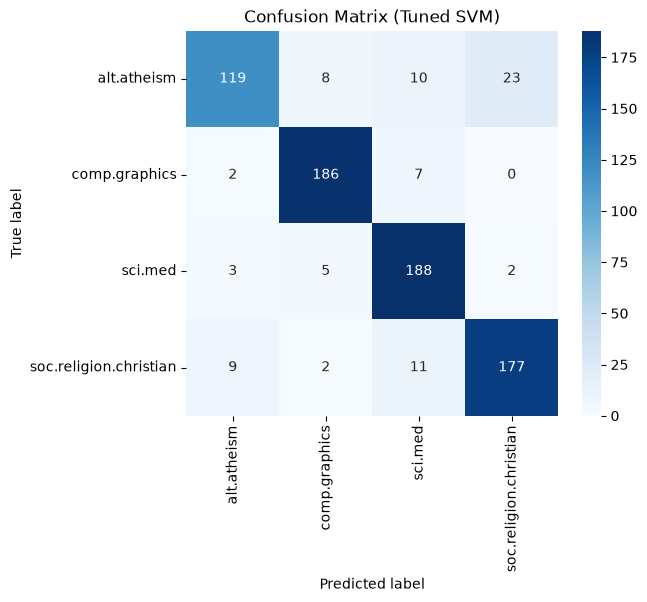

In [10]:
# -------------------------------------------------
# 8️⃣  Use the best estimator from GridSearch
# -------------------------------------------------
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test_vec)

print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report (Tuned):\n",
      classification_report(y_test, y_pred_best,
                            target_names=newsgroups.target_names))

# Optional: Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=newsgroups.target_names,
            yticklabels=newsgroups.target_names)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix (Tuned SVM)')
plt.show()# -------------------------------------------------
# 8️⃣  Use the best estimator from GridSearch
# -------------------------------------------------
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test_vec)

print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report (Tuned):\n",
      classification_report(y_test, y_pred_best,
                            target_names=newsgroups.target_names))

# Optional: Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=newsgroups.target_names,
            yticklabels=newsgroups.target_names)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix (Tuned SVM)')
plt.show()

In [11]:
# -------------------------------------------------
# 9️⃣  Persist the trained artifacts with joblib
# -------------------------------------------------
import joblib

joblib.dump(best_svm, 'svm_text_classifier.pkl')
joblib.dump(tfidf,    'tfidf_vectorizer.pkl')
print("Model and vectorizer saved to disk.")

Model and vectorizer saved to disk.


In [12]:
# -------------------------------------------------
# 🔟  Load the saved objects and predict on new sentences
# -------------------------------------------------
loaded_svm = joblib.load('svm_text_classifier.pkl')
loaded_tfidf = joblib.load('tfidf_vectorizer.pkl')

new_texts = [
    "The latest GPU architecture delivers stunning graphics performance.",
    "Patients reported side effects after the new medication trial."
]

new_vec = loaded_tfidf.transform(new_texts)
preds = loaded_svm.predict(new_vec)

for txt, p in zip(new_texts, preds):
    print(f"Text: {txt}\nPredicted class: {newsgroups.target_names[p]}\n")

Text: The latest GPU architecture delivers stunning graphics performance.
Predicted class: comp.graphics

Text: Patients reported side effects after the new medication trial.
Predicted class: sci.med

